In [2]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import r2_score
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import geopandas as gpd
from pathlib import Path
import sys
from tabulate import tabulate
from pathlib import Path
PROJECT_ROOT = next(
    p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / "Scripts").is_dir()
)
scripts_directory = PROJECT_ROOT / 'Scripts' / 'Helpers'

# Convert the Path object to a string and append it to sys.path
if str(scripts_directory) not in sys.path:
    sys.path.append(str(scripts_directory))
from Helpers import *



In [3]:
cols = ["MSA",
    "Intellectual Property Law_binary_count",       
    "Immigration Law_binary_count",                
    "Corporate / Business Law_binary_count",        
    "Tax Law_binary_count",                        
    "Employment / Labor Law_binary_count",          
    "Civil Litigation_binary_count",               
    "Personal Injury / Torts_binary_count",         
    "Bankruptcy Law_binary_count",                  
    "total_unique_lawyers",            
    "Real Estate Law_binary_count",                 
    "Criminal Defense_binary_count",                
    "Family Law_binary_count",                     
    "Estate Planning / Probate / Trusts_binary_count",'B01003_001E', 'land_area_sqmi'
]
df = pd.read_csv(PROJECT_ROOT/"Data/BrightData_Lawyers/BrightData_Lawyers_master.csv")
df.rename(columns={"n_lawyers": "total_unique_lawyers"}, inplace=True)
df["MSA Code"] = (pd.to_numeric(df["CBSA"], errors="coerce") // 10).astype("Int64")
gdf = gpd.read_file(PROJECT_ROOT/"Data/Geography/CBSA_shapefile_2025/tl_2025_us_cbsa.shp")[["GEOID", "NAMELSAD", "ALAND"]]
gdf = gdf[gdf["NAMELSAD"].str.contains("Metro Area", na=False)]
gdf["MSA Code"] = gdf["GEOID"].str[:-1].astype(int)
gdf["land_area_sqmi"] = gdf["ALAND"] / 2589988.110336
df_bls = pd.read_csv(PROJECT_ROOT/"Data/Population Data/MSA Population/ACSDT1Y2024.B01003-Data.csv")[["GEO_ID", "NAME", "B01003_001E"]]
df_bls = df_bls[df_bls["NAME"].str.contains("Metro Area", na=False)]
df_bls["MSA Code"] = df_bls["GEO_ID"].str[-5:].str[:-1].astype(int)
df = df.merge(df_bls[["MSA Code", "B01003_001E"]], on="MSA Code", how="left")
df = df.merge(gdf[["MSA Code", "land_area_sqmi"]], on="MSA Code", how="left")
df = df[cols]
df[cols[1:]] = df[cols[1:]].apply(pd.to_numeric, errors="coerce")
df = df.dropna()
df["Total"] = df["total_unique_lawyers"]

In [4]:
laws = [
    "Intellectual Property Law_binary_count",       
    "Immigration Law_binary_count",                
    "Corporate / Business Law_binary_count",        
    "Tax Law_binary_count",                        
    "Employment / Labor Law_binary_count",          
    "Civil Litigation_binary_count",               
    "Personal Injury / Torts_binary_count",         
    "Bankruptcy Law_binary_count",                  
    "total_unique_lawyers",            
    "Real Estate Law_binary_count",                 
    "Criminal Defense_binary_count",                
    "Family Law_binary_count",                     
    "Estate Planning / Probate / Trusts_binary_count",
]

# Prepare data per method
pop_betas, pop_low, pop_high = [], [], []
dens_betas, dens_low, dens_high = [], [], []
cd_betas, cd_low, cd_high = [], [], []
cd_sum, cd_sum_low, cd_sum_high = [], [], []
pop_r2, dens_r2, cd_r2 = [], [], []
pop_ols_betas, pop_ols_low, pop_ols_high = [], [], []
pop_ols_r2 = []
sample_size = []
y_labels = []
laws_used = []

def display_law_name(law):
    if law == "total_unique_lawyers":
        return "Total Lawyers"
    return law.replace("_binary_count", "")
    

for law in laws:
    df_reg = df[[law, "B01003_001E", "land_area_sqmi"]]
    df_reg = df_reg[df_reg[law] > 0]
    if len(df_reg) == 0:
        continue

    P = df_reg["B01003_001E"].values
    A = df_reg["land_area_sqmi"].values
    L = df_reg[law].values

    sample_size.append(len(df_reg))
    laws_used.append(law)
    y_labels.append(display_law_name(law))

    # Population (Bayesian)
    beta, ci_low, ci_high, r2 = scale(P, L)
    pop_betas.append(beta)
    pop_low.append(ci_low)
    pop_high.append(ci_high)
    pop_r2.append(r2)
    
    # Population (OLS) 
    beta_ols, ci_low_ols, ci_high_ols, r2_ols = scale_ols(P, L)
    pop_ols_betas.append(beta_ols)
    pop_ols_low.append(ci_low_ols)
    pop_ols_high.append(ci_high_ols)
    pop_ols_r2.append(r2_ols)
    
    beta, ci_low, ci_high, r2 = scale(A, L)
    dens_betas.append(beta)
    dens_low.append(ci_low)
    dens_high.append(ci_high)
    dens_r2.append(r2)
    
    # Cobb-Douglas
    beta_cd, ci_cd_low, ci_cd_high, sum_cd_val, sum_cd_low_val, sum_cd_high_val, r2 = cob(L, P, A)
    
    cd_betas.append(beta_cd)
    cd_low.append(ci_cd_low)
    cd_high.append(ci_cd_high)
    cd_sum.append(sum_cd_val)
    cd_sum_low.append(sum_cd_low_val)
    cd_sum_high.append(sum_cd_high_val)
    cd_r2.append(r2)
# Global order: ascending Bayesian population beta
order = np.argsort(np.array(pop_betas))

def reorder(x):
    return [x[i] for i in order]

laws = reorder(laws_used)
y_labels = reorder(y_labels)
sample_size = reorder(sample_size)

pop_betas = reorder(pop_betas)
pop_low = reorder(pop_low)
pop_high = reorder(pop_high)
pop_r2 = reorder(pop_r2)

pop_ols_betas = reorder(pop_ols_betas)
pop_ols_low = reorder(pop_ols_low)
pop_ols_high = reorder(pop_ols_high)
pop_ols_r2 = reorder(pop_ols_r2)

dens_betas = reorder(dens_betas)
dens_low = reorder(dens_low)
dens_high = reorder(dens_high)
dens_r2 = reorder(dens_r2)

cd_betas = reorder(cd_betas)
cd_low = reorder(cd_low)
cd_high = reorder(cd_high)
cd_sum = reorder(cd_sum)
cd_sum_low = reorder(cd_sum_low)
cd_sum_high = reorder(cd_sum_high)
cd_r2 = reorder(cd_r2)

# Save the same specialty order for other plots/notebooks
specialty_order_betaP = [
    law.replace("_binary_count", "")
    for law in laws
    if law != "total_unique_lawyers"
]

laws_binary_order_betaP = [
    f"{name}_binary_count" for name in specialty_order_betaP
]


In [5]:
def estimate_ci(estimate, ci_low, ci_high):
    return f"{estimate:.3f} ({ci_low:.3f}, {ci_high:.3f})"


cobb_table = pd.DataFrame({
    "Law": y_labels,

    "alpha_P (95% CI)": [
        estimate_ci(beta[0], low[0], high[0])
        for beta, low, high in zip(cd_betas, cd_low, cd_high)
    ],

    "alpha_A (95% CI)": [
        estimate_ci(beta[1], low[1], high[1])
        for beta, low, high in zip(cd_betas, cd_low, cd_high)
    ],

    "sum (95% CI)": [
        estimate_ci(value, low, high)
        for value, low, high in zip(
            cd_sum,
            cd_sum_low,
            cd_sum_high
        )
    ]
})


cobb_table.style.format(na_rep="").hide(axis="index")

Law,alpha_P (95% CI),alpha_A (95% CI),sum (95% CI)
Family Law,"1.033 (0.992, 1.073)","0.009 (-0.054, 0.072)","1.041 (0.989, 1.094)"
Estate Planning / Probate / Trusts,"1.067 (1.018, 1.116)","-0.025 (-0.096, 0.045)","1.042 (0.984, 1.100)"
Criminal Defense,"1.040 (1.000, 1.080)","0.083 (0.024, 0.141)","1.123 (1.072, 1.174)"
Bankruptcy Law,"1.170 (1.114, 1.226)","0.018 (-0.063, 0.100)","1.189 (1.124, 1.254)"
Personal Injury / Torts,"1.153 (1.093, 1.213)","0.062 (-0.024, 0.151)","1.215 (1.150, 1.281)"
Real Estate Law,"1.189 (1.134, 1.243)","-0.004 (-0.087, 0.080)","1.185 (1.121, 1.248)"
Total Lawyers,"1.231 (1.177, 1.284)","0.018 (-0.061, 0.098)","1.249 (1.187, 1.312)"
Civil Litigation,"1.217 (1.160, 1.274)","0.056 (-0.032, 0.143)","1.273 (1.203, 1.341)"
Employment / Labor Law,"1.255 (1.181, 1.330)","0.039 (-0.070, 0.148)","1.294 (1.220, 1.370)"
Corporate / Business Law,"1.279 (1.217, 1.341)","0.058 (-0.039, 0.155)","1.337 (1.261, 1.412)"


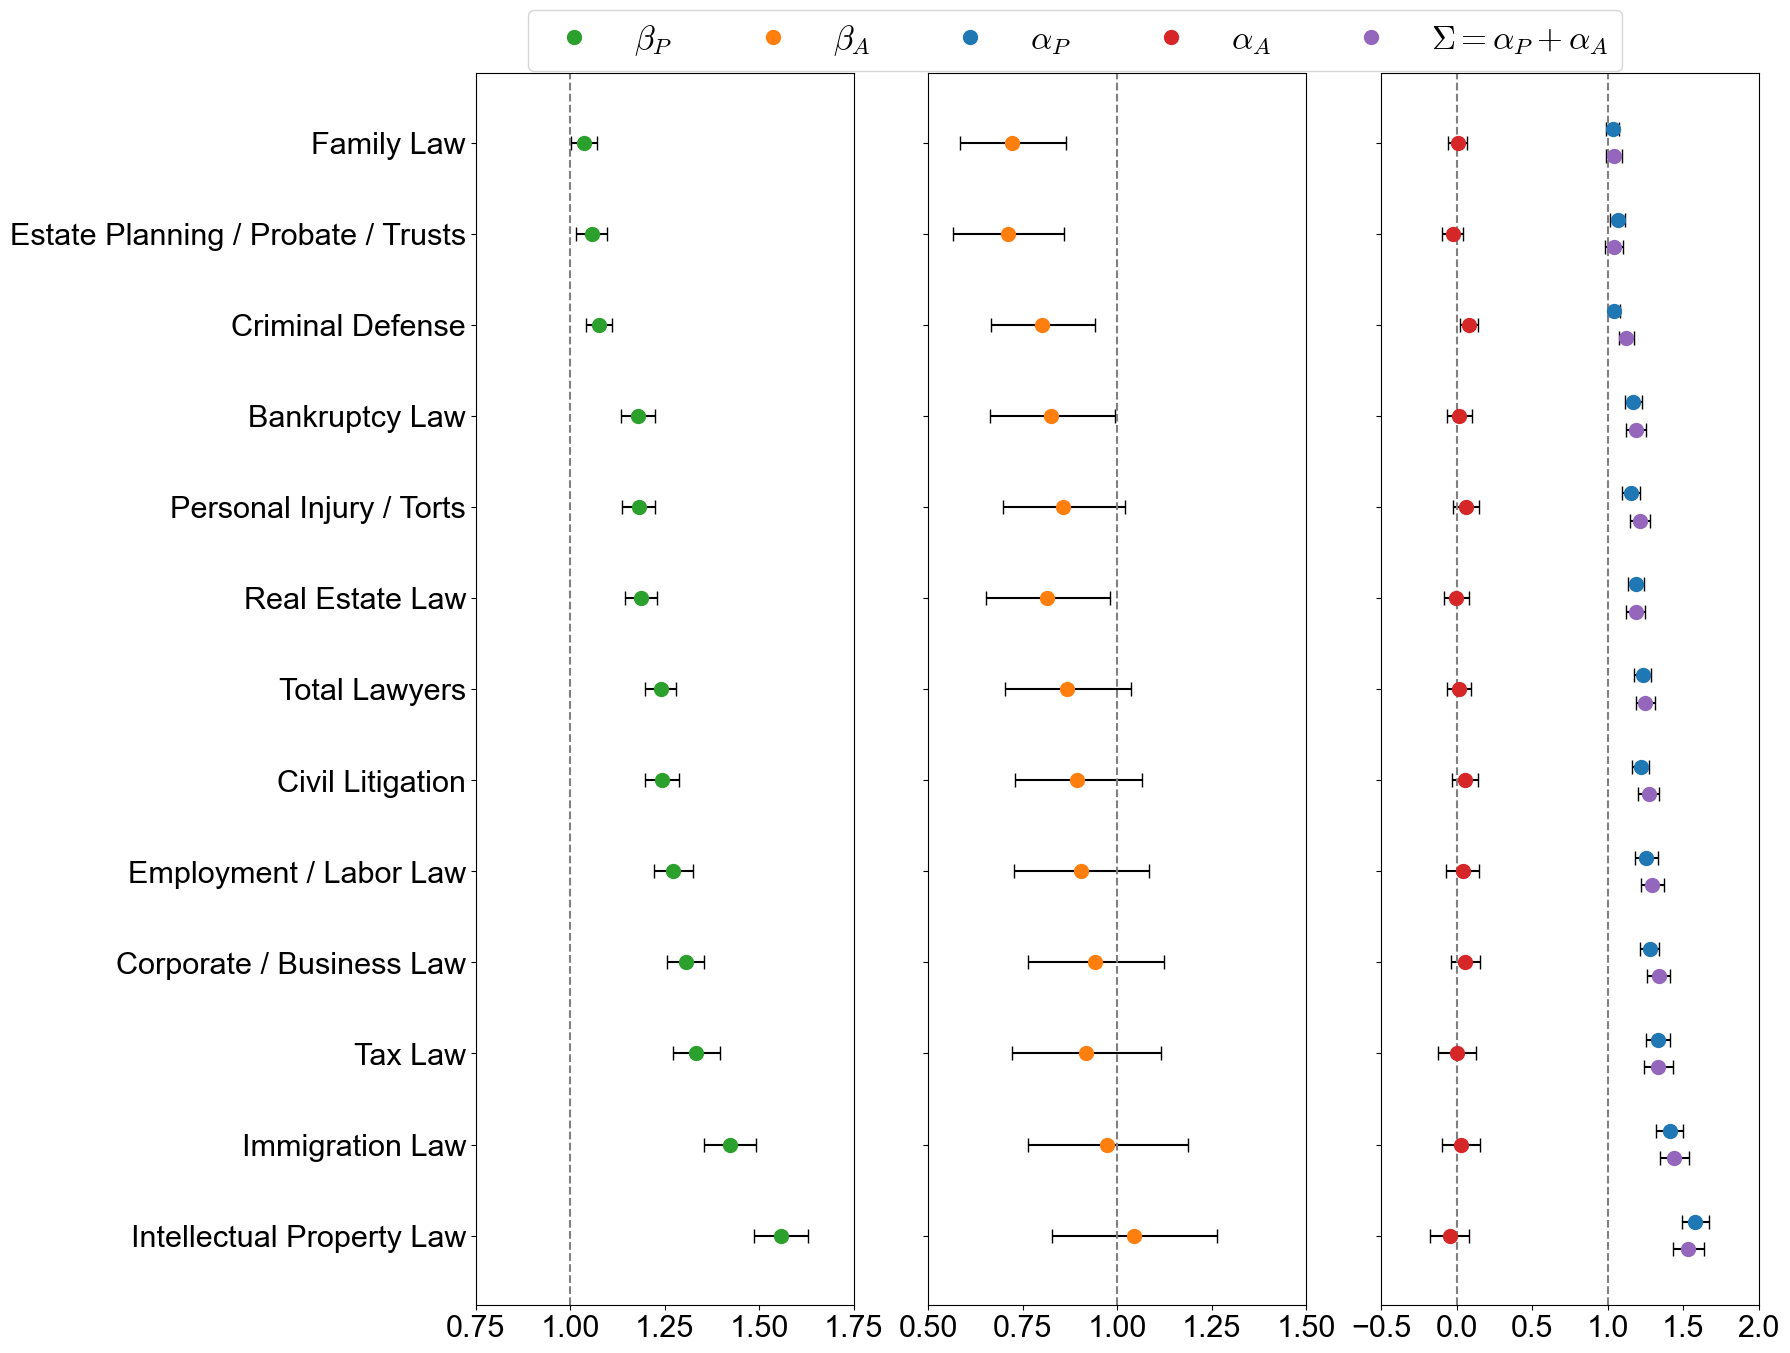

In [18]:
plt.rcParams.update({
    'axes.titlesize': 20,      # plot titles
    'axes.labelsize': 22,      # x and y labels
    'xtick.labelsize': 22,     # x-axis tick labels
    'ytick.labelsize': 22,     # y-axis tick labels
    'legend.fontsize': 24,
    "font.family":"arial",
    #"font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "mathtext.default": "rm",
    "mathtext.rm"  : "arial",# legend
})



# --- Visualization with R², corrected xerr, and single top legend ---

fig, axes = plt.subplots(1, 3, figsize=(18, len(y_labels)*1), sharey=True)

# Population plot
axes[0].errorbar(
    pop_betas,
    range(len(y_labels)),
    xerr=[np.abs(np.array(pop_betas) - np.array(pop_low)),
          np.abs(np.array(pop_high) - np.array(pop_betas))],
    fmt='o', color='C2', ecolor='black', capsize=5, markersize=10
)
# axes[0].scatter(pop_r2, range(len(y_labels)), marker='D', color='black')

# Density plot
axes[1].errorbar(
    dens_betas,
    range(len(y_labels)),
    xerr=[np.abs(np.array(dens_betas) - np.array(dens_low)),
          np.abs(np.array(dens_high) - np.array(dens_betas))],
    fmt='o', color='C1', ecolor='black', capsize=5, markersize=10
)
# axes[1].scatter(dens_r2, range(len(y_labels)), marker='D', color='black')

# Cobb-Douglas plot
for i, (betas, lows, highs, sum_beta, sum_low, sum_high, r2) in enumerate(
        zip(cd_betas, cd_low, cd_high, cd_sum, cd_sum_low, cd_sum_high, cd_r2)):
    
    # Beta1
    axes[2].errorbar(
        betas[0], i-0.15,
        xerr=[[np.abs(betas[0]-lows[0])], [np.abs(highs[0]-betas[0])]],
        fmt='o', color='C0', ecolor='black', capsize=5, markersize=10
    )
    
    # Beta2
    axes[2].errorbar(
        betas[1], i,
        xerr=[[np.abs(betas[1]-lows[1])], [np.abs(highs[1]-betas[1])]],
        fmt='o', color='C3', ecolor='black', capsize=5, markersize=10
    )
    
    # Sum of betas
    axes[2].errorbar(
        sum_beta, i+0.15,
        xerr=[[np.abs(sum_beta - sum_low)], [np.abs(sum_high - sum_beta)]],
        fmt='o', color='C4', ecolor='black', capsize=5, markersize=10
    )
    
    # R² as black diamond
    # axes[2].scatter(r2, i, marker='D', color='black')

# Remove subplot titles
for ax in axes:
    ax.set_title("")

axes[0].set_xlim([0.75,1.75])
axes[1].set_xlim([0.5,1.5])
axes[2].set_xlim([-0.5,2])
axes[2].set_xticks([-0.5,0,0.5,1,1.5,2])

# Y-axis labels
axes[0].set_yticks(range(len(y_labels)))
axes[0].set_yticklabels(y_labels, rotation=0)
axes[0].invert_yaxis()

# Vertical reference lines
for ax in axes:
    ax.axvline(x=1, color='gray', linestyle='--')
axes[2].axvline(x=0, color='gray', linestyle='--')

# Create a single legend above all subplots
legend_elements = [
    # Line2D([0], [0], marker='D', color='black', label=r'$R^2$', linestyle='None'),
    Line2D([0], [0], marker='o', markersize=10, color='C2', label=r'$\it{\beta_P}$', linestyle='None'),
    Line2D([0], [0], marker='o', markersize=10, color='C1', label=r'$\it{\beta_A}$', linestyle='None'),
    Line2D([0], [0], marker='o', markersize=10, color='C0', label=r'$\it{\alpha_P}$', linestyle='None'),
    Line2D([0], [0], marker='o', markersize=10, color='C3', label=r'$\it{\alpha_A}$', linestyle='None'),
    Line2D([0], [0], marker='o', markersize=10, color='C4', label=r'$\it{\Sigma = \alpha_P+\alpha_A}$', linestyle='None')]

fig.legend(handles=legend_elements, loc='upper center', ncol=len(legend_elements), bbox_to_anchor=(0.6, 1.05))
plt.tight_layout()
# Define the output directory and ensure it exists
save_dir = PROJECT_ROOT/"Figures/Figure 2"
save_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(save_dir / "Figure_2.pdf", bbox_inches='tight')
plt.show()

In [19]:
R2_df = pd.DataFrame({
    "Law": y_labels,
    "n": sample_size,
    "Population": pop_r2,
    "Area": dens_r2,
    "Cobb-Douglas": cd_r2
})

R2_df.style.format({
    "Population": "{:.3f}",
    "Area": "{:.3f}",
    "Cobb-Douglas": "{:.3f}"
}).hide(axis="index")

Law,n,Population,Area,Cobb-Douglas
Family Law,382,0.882,0.276,0.882
Estate Planning / Probate / Trusts,382,0.857,0.251,0.857
Criminal Defense,382,0.887,0.316,0.889
Bankruptcy Law,382,0.841,0.266,0.841
Personal Injury / Torts,382,0.838,0.285,0.839
Real Estate Law,382,0.866,0.264,0.866
Total Lawyers,382,0.888,0.281,0.888
Civil Litigation,382,0.863,0.290,0.864
Employment / Labor Law,382,0.829,0.271,0.830
Corporate / Business Law,382,0.859,0.288,0.860


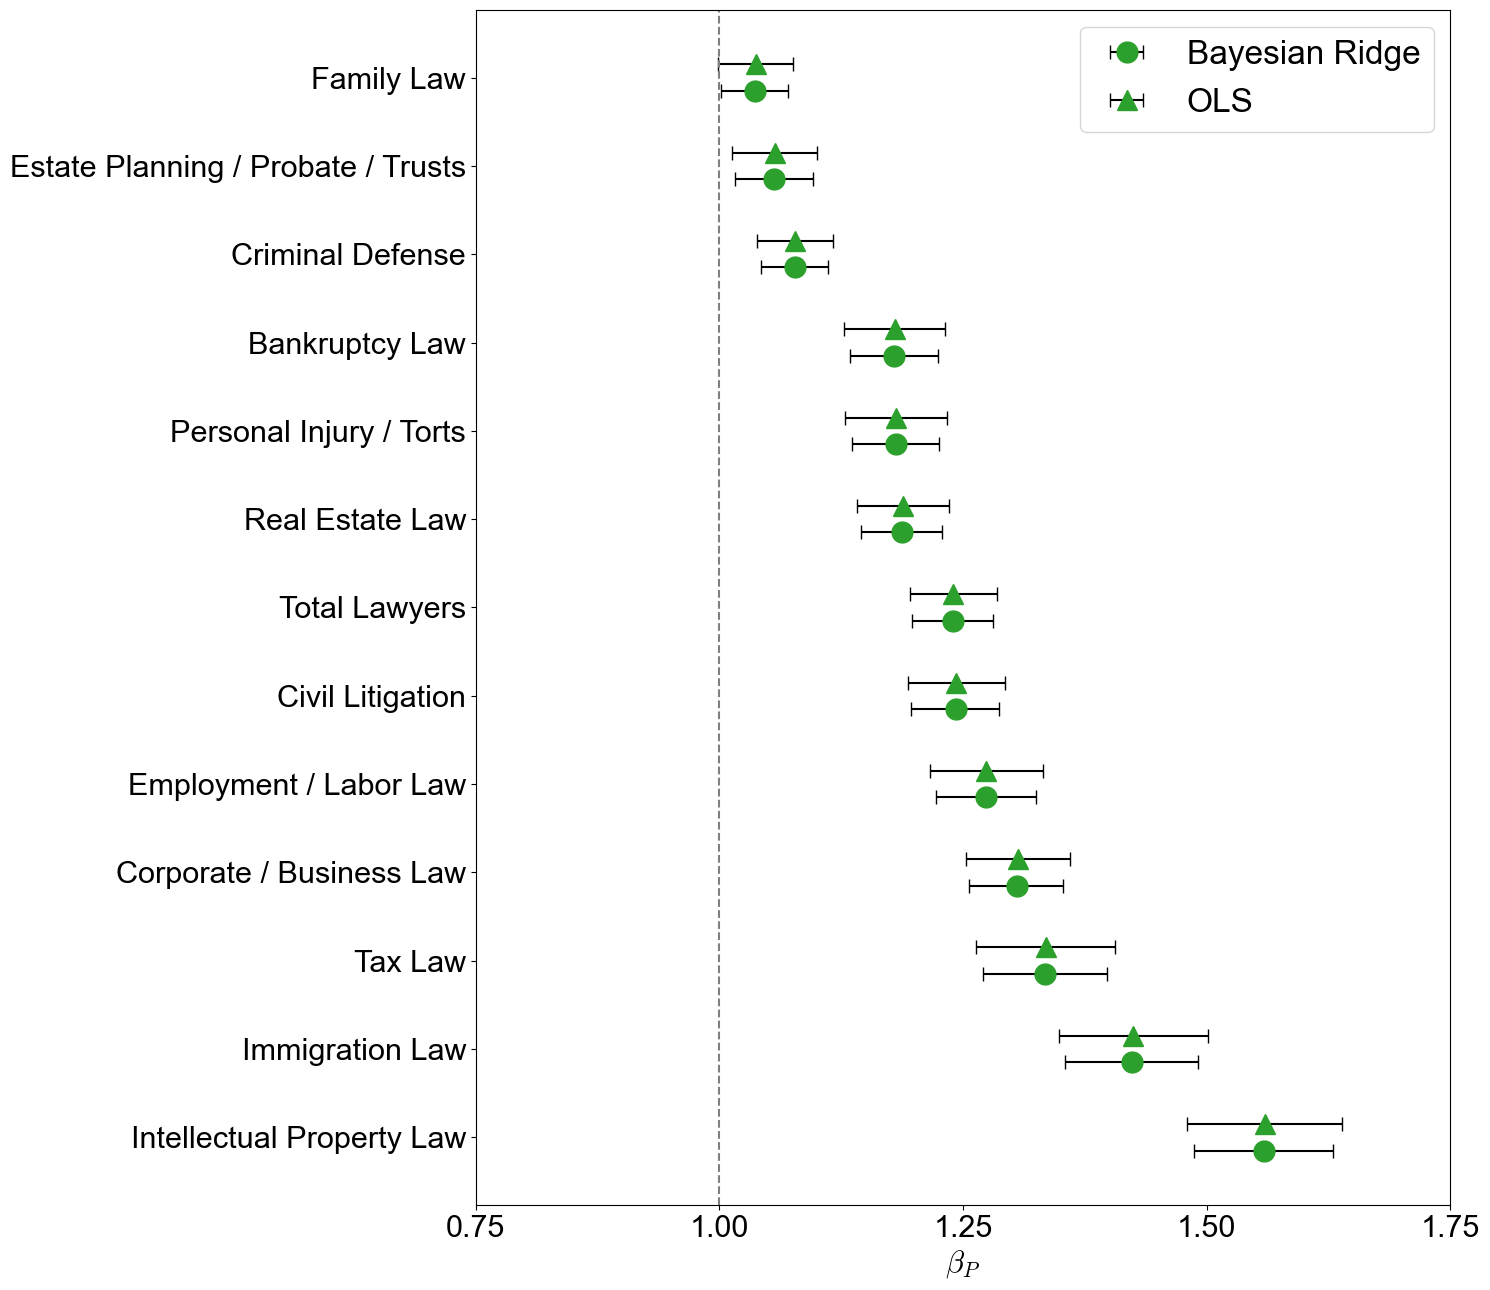

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(15, len(y_labels) * 1))

y = np.arange(len(y_labels))
offset = 0.15  # vertical separation amount

# --- Bayesian Ridge (slightly above) ---
ax.errorbar(
    pop_betas,
    y + offset,
    xerr=[np.abs(np.array(pop_betas) - np.array(pop_low)),
          np.abs(np.array(pop_high) - np.array(pop_betas))],
    fmt='o', color='C2', ecolor='black', capsize=5, 
    markersize=15, label="Bayesian Ridge"
)

# --- OLS (slightly below) ---
ax.errorbar(
    pop_ols_betas,
    y - offset,
    xerr=[np.abs(np.array(pop_ols_betas) - np.array(pop_ols_low)),
          np.abs(np.array(pop_ols_high) - np.array(pop_ols_betas))],
    fmt='^', color='C2', ecolor='black', capsize=5,  
    markersize=15, label="OLS"
)

ax.set_xlabel(r'$\it{\beta_P}$')
# --- Formatting ---
ax.set_yticks(y)
ax.set_yticklabels(y_labels)
ax.invert_yaxis()

ax.set_xlim([0.75, 1.75])
ax.set_xticks([0.75, 1, 1.25, 1.5, 1.75])

ax.axvline(x=1, color='gray', linestyle='--')

ax.legend()

plt.tight_layout()
# Define the output directory and ensure it exists
save_dir = PROJECT_ROOT/"Figures/Supplementary Figure 5"
save_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(save_dir / "Supplementary_Figure_5.pdf", bbox_inches='tight')
plt.show()